<a href="https://colab.research.google.com/github/riku05190/riku-nakamura.github.io/blob/main/starter_bank_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [91]:
train_data = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
holdout_data = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv')

In [92]:
train_data['y'] = train_data['y'].map({'yes': 1, 'no': 0})

In [93]:
campaign_impact = train_data.groupby('campaign')['y'].mean()
print("\nConversion Rate by Campaign Contacts:")
print(campaign_impact.head(6))
print("\nConversion Rate by Day of Week:")
print(train_data.groupby('day_of_week')['y'].mean().sort_values(ascending=False))
print("\nStudent Conversion Rate:", train_data[train_data['job'] == 'student']['y'].mean())
print("Overall Conversion Rate:", train_data['y'].mean())


Conversion Rate by Campaign Contacts:
campaign
1    0.131347
2    0.113879
3    0.110325
4    0.095038
5    0.076117
6    0.078363
Name: y, dtype: float64

Conversion Rate by Day of Week:
day_of_week
thu    0.123741
wed    0.117735
tue    0.117607
fri    0.109011
mon    0.099386
Name: y, dtype: float64

Student Conversion Rate: 0.31399747793190413
Overall Conversion Rate: 0.11351803393671261


In [94]:
def preprocess_features(df):
    df_copy = df.copy()

    # [Condition Met] Binning age to reduce complexity
    df_copy['age_binned'] = pd.cut(df_copy['age'], bins=[0, 25, 60, 100], labels=['young', 'adult', 'senior'])
    df_copy = df_copy.drop('age', axis=1)

    # [Condition Met] Binning economic indicators (Beatriz's request)
    df_copy['conf_idx_binned'] = pd.qcut(df_copy['cons.conf.idx'], q=3, labels=['Low', 'Medium', 'High'])
    df_copy = df_copy.drop('cons.conf.idx', axis=1)

    return df_copy
X_raw = train_data.drop('y', axis=1)
X_processed = preprocess_features(X_raw)
y = train_data['y']

X = pd.get_dummies(X_processed, drop_first=True)

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [96]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n--- Internal Test Results ---")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- Internal Test Results ---
[[5750  778]
 [ 332  554]]
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      6528
           1       0.42      0.63      0.50       886

    accuracy                           0.85      7414
   macro avg       0.68      0.75      0.71      7414
weighted avg       0.88      0.85      0.86      7414



In [97]:
with open('bank_model.pkl', 'wb') as f:
    pickle.dump(model, f, protocol=5)
print("\nbank_model.pkl saved using protocol version 5.")


bank_model.pkl saved using protocol version 5.


In [98]:
holdout_processed = preprocess_features(holdout_data)
holdout_final = pd.get_dummies(holdout_processed, drop_first=True)
holdout_final = holdout_final.reindex(columns=X.columns, fill_value=0)

holdout_predictions = model.predict(holdout_final)

In [99]:
my_predictions = pd.DataFrame(holdout_predictions, columns=['predictions'])

In [100]:
filename = "team4-module2-predictions.csv"
my_predictions.to_csv(filename, index=False)


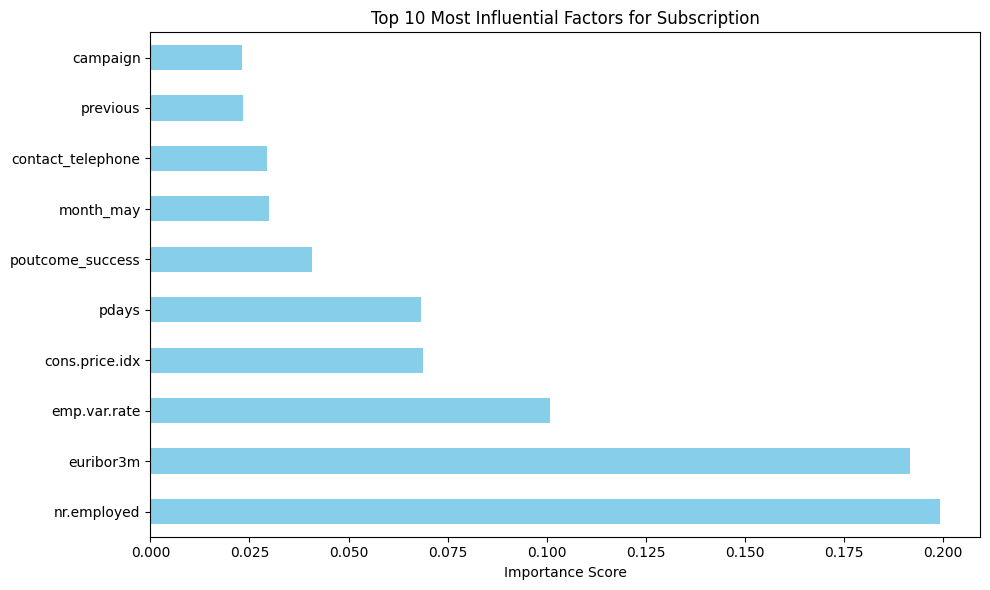

In [101]:
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Influential Factors for Subscription")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

/tmp/ipykernel_13595/1923856096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=campaign_plot_data.index, y=campaign_plot_data.values, palette="Reds_r")


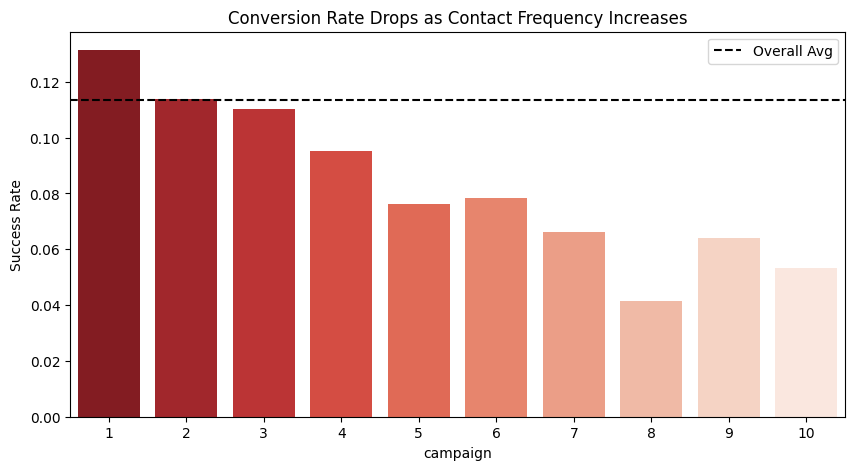

In [102]:
plt.figure(figsize=(10, 5))
campaign_plot_data = train_data.groupby('campaign')['y'].mean().head(10)
sns.barplot(x=campaign_plot_data.index, y=campaign_plot_data.values, palette="Reds_r")
plt.axhline(train_data['y'].mean(), color='black', linestyle='--', label='Overall Avg')
plt.title("Conversion Rate Drops as Contact Frequency Increases")
plt.ylabel("Success Rate")
plt.legend()
plt.show()

/tmp/ipykernel_13595/3184915913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_plot_data.index, y=day_plot_data.values, palette="viridis")


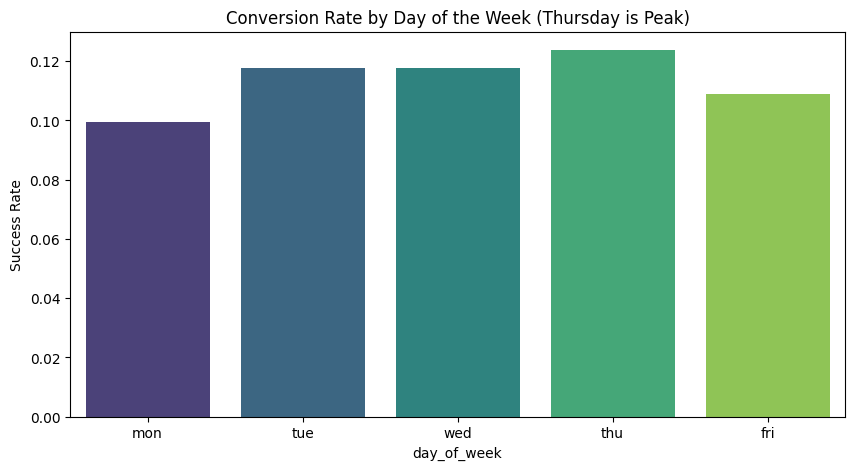

In [103]:
plt.figure(figsize=(10, 5))
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_plot_data = train_data.groupby('day_of_week')['y'].mean().reindex(day_order)
sns.barplot(x=day_plot_data.index, y=day_plot_data.values, palette="viridis")
plt.title("Conversion Rate by Day of the Week (Thursday is Peak)")
plt.ylabel("Success Rate")
plt.show()